STEP 1: CT SCAN IMAGES UPLOAD

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.0 MB/s eta 0:00:00


In [2]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random
import matplotlib.image as mpimg
import tensorflow as tf




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import zipfile
import os

# Replace 'baggage_dataset.zip' with your uploaded file name
with zipfile.ZipFile("/content/Threat_detection.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")  # extracts into a folder named "dataset"

# Check structure
os.listdir("dataset")

['ThreatsRGB', 'HighLow', 'NotThreats']

DATA PREPROCESSING

Folders: ['ThreatsRGB', 'HighLow', 'NotThreats']


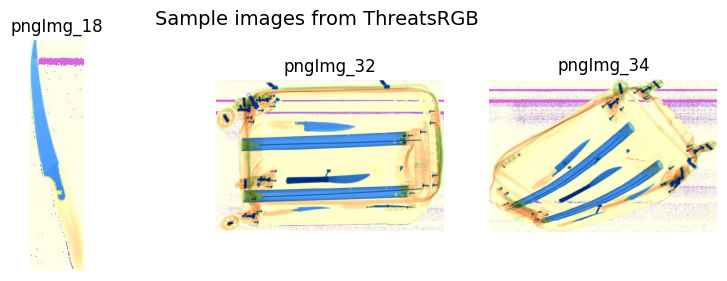

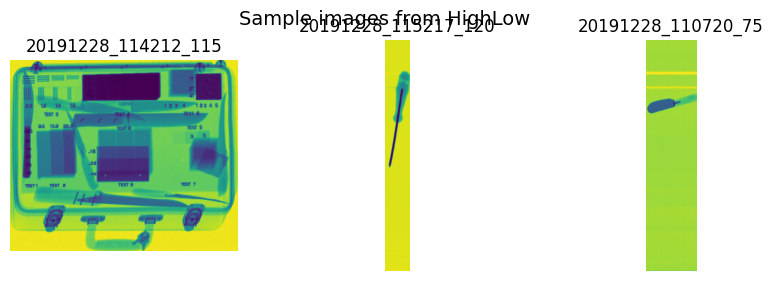

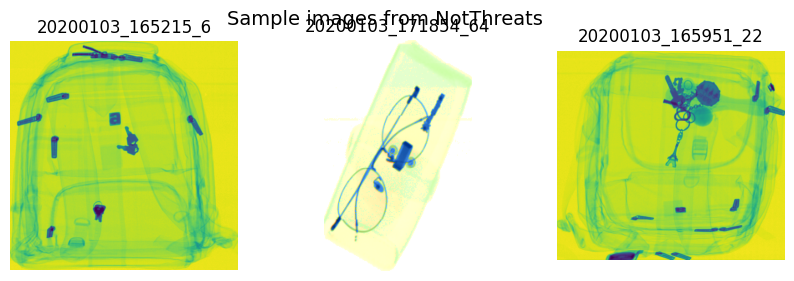

In [6]:
# Step 3: List folders
dataset_path = "dataset"
folders = os.listdir(dataset_path)
print("Folders:", folders)

# Step 4: Show 3 sample images from each folder
for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    images = os.listdir(folder_path)

    # Pick 3 random images
    sample_images = random.sample(images, min(3, len(images)))

    plt.figure(figsize=(10,3))
    plt.suptitle(f"Sample images from {folder}", fontsize=14)

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(folder_path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_name.split('.')[0])

    plt.show()







CHECK DATASET INFORMATION

In [7]:
# Count images in each folder
dataset_path = "dataset"
folders = os.listdir(dataset_path)

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    num_images = len(os.listdir(folder_path))

    print(f"{folder} : {num_images} images")

ThreatsRGB : 150 images
HighLow : 165 images
NotThreats : 275 images


TRAINING - 80%

In [8]:
# Dataset path
dataset_path = "dataset"

# Load dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),   # resize images
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)


Found 150 files belonging to 3 classes.
Using 120 files for training.


VALIDATION - 20%

In [9]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 150 files belonging to 3 classes.
Using 30 files for validation.


NORMALIZATION

In [10]:
# Normalize training and validation datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

DATA AUGMENTATION

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Apply to training dataset
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

In [12]:
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

TRAINING THE DATA

In [13]:
dataset_path = "dataset/images"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:  # show only first 5 images per folder
        print(f"{indent}    {f}")

YOLOv8

In [14]:
# Load pretrained YOLOv8 small model
model = YOLO('yolov8n.pt')

In [15]:
model = YOLO("yolov8n-cls.pt")   # classification model

model.train(
    data="dataset",        # IMPORTANT: point to dataset root
    epochs=20,
    imgsz=224,
    batch=16,
    name="baggage_classification"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baggage_classification, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e2878552000>
curves: []
curves_results: []
fitness: 0.991525411605835
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9830508232116699, 'metrics/accuracy_top5': 1.0, 'fitness': 0.991525411605835}
save_dir: PosixPath('/content/runs/classify/baggage_classification')
speed: {'preprocess': 0.24068961017091772, 'inference': 1.1991102881330657, 'loss': 0.0003491779653366825, 'postprocess': 0.0004971186395562392}
top1: 0.9830508232116699
top5: 1.0

TEST

In [16]:
model.predict("/content/dataset_split/val/ThreatsRGB", show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/51 /content/dataset_split/val/ThreatsRGB/image_0_1135.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.4ms
image 2/51 /content/dataset_split/val/ThreatsRGB/image_0_1212.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.5ms
image 3/51 /content/dataset_split/val/ThreatsRGB/image_0_1222.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.5ms
image 4/51 /content/dataset_split/val/ThreatsRGB/image_0_1241.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.2ms
image 5/51 /content/dataset_split/val/ThreatsRGB/image_0_129.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.4ms
image 6/51 /content/dataset_split/val/ThreatsRGB/image_0_1293.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.3ms
image 7/51 /content/dataset_split/val/ThreatsRGB/image_0_1305.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.3ms
image 8/51 /content/dat

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'HighLow', 1: 'NotThreats', 2: 'ThreatsRGB'}
 obb: None
 orig_img: array([[[239, 240, 160],
         [247, 248, 174],
         [255, 255, 205],
         ...,
         [255, 255, 252],
         [255, 255, 252],
         [255, 255, 252]],
 
        [[238, 242, 160],
         [246, 248, 172],
         [255, 255, 203],
         ...,
         [255, 255, 254],
         [255, 255, 254],
         [255, 255, 254]],
 
        [[239, 248, 158],
         [243, 249, 170],
         [255, 255, 203],
         ...,
         [253, 255, 255],
         [253, 255, 255],
         [253, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [254, 254, 254],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255

MODEL EVALUATION

In [17]:
results = model.predict("/content/dataset_split/val/ThreatsRGB")




image 1/51 /content/dataset_split/val/ThreatsRGB/image_0_1135.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 5.5ms
image 2/51 /content/dataset_split/val/ThreatsRGB/image_0_1212.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.5ms
image 3/51 /content/dataset_split/val/ThreatsRGB/image_0_1222.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.4ms
image 4/51 /content/dataset_split/val/ThreatsRGB/image_0_1241.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.3ms
image 5/51 /content/dataset_split/val/ThreatsRGB/image_0_129.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.3ms
image 6/51 /content/dataset_split/val/ThreatsRGB/image_0_1293.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.3ms
image 7/51 /content/dataset_split/val/ThreatsRGB/image_0_1305.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 2.4ms
image 8/51 /content/dataset_split/val/ThreatsRGB/image_0_1480.jpg: 224x224 ThreatsRGB 1.00, HighL

In [18]:
print("Predicted class:", results[0].names[results[0].probs.top1])
print("Confidence:", results[0].probs.top1conf)

Predicted class: ThreatsRGB
Confidence: tensor(1.0000, device='cuda:0')


CONVERTED IMAGES TO .JPG

In [19]:
from PIL import Image
import os
import shutil

# Base folder containing your split folders
base_folder = "/content/dataset_split"

# Iterate through splits and class folders
for split in ["train", "val", "test"]:
    split_path = os.path.join(base_folder, split)
    if not os.path.exists(split_path):
        continue

    for class_folder in os.listdir(split_path):
        class_path = os.path.join(split_path, class_folder)
        if not os.path.isdir(class_path):
            continue

        # Create a new folder for converted images
        converted_folder = class_path + "_jpg"
        os.makedirs(converted_folder, exist_ok=True)

        for file in os.listdir(class_path):
            if file.lower().endswith(".tif"):
                img_path = os.path.join(class_path, file)
                img = Image.open(img_path)

                # Convert to RGB if needed
                if img.mode != "RGB":
                    img = img.convert("RGB")

                # Save as JPG
                new_name = os.path.splitext(file)[0] + ".jpg"
                img.save(os.path.join(converted_folder, new_name))

print("All .tif images converted to .jpg successfully!")

All .tif images converted to .jpg successfully!


In [23]:
val_folder = "/content/dataset_split/val/NotThreats_jpg"

EVALUATION STEP **HIGH LOW MODEL EVALUATION**

In [25]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Correct test folders (where your images actually are)
test_folders = [
    "/content/dataset_split/train/HighLow_jpg",

]

for folder in test_folders:
    print(f"Testing images in folder: {folder}\n{'-'*50}")

    # Include only image files
    image_files = [os.path.join(folder, f)
                   for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print("No images found!\n")
        continue

    for img_path in image_files:
        results = model(img_path)  # run prediction
        probs = results[0].probs   # get probabilities object

        pred_index = int(probs.top1)          # predicted class index
        confidence = float(probs.top1conf)    # confidence
        class_name = results[0].names[pred_index]  # class name

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted class: {class_name}, Confidence: {confidence:.2f}\n")

Testing images in folder: /content/dataset_split/train/HighLow_jpg
--------------------------------------------------

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_115410_124.xif_lo.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 9.9ms
Speed: 4.4ms preprocess, 9.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20191228_115410_124.xif_lo.jpg
Predicted class: HighLow, Confidence: 0.76


image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_113046_94.xif_hi.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 5.1ms
Speed: 7.6ms preprocess, 5.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20191228_113046_94.xif_hi.jpg
Predicted class: HighLow, Confidence: 0.76


image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_115900_135.xif_lo.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 4.9ms
Speed: 8.4ms preprocess, 4.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224,

THREAT MODEL EVALUATION

In [27]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Correct test folders (where your images actually are)
test_folders = [
    "/content/dataset_split/train/ThreatsRGB",

]

for folder in test_folders:
    print(f"Testing images in folder: {folder}\n{'-'*50}")

    # Include only image files
    image_files = [os.path.join(folder, f)
                   for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print("No images found!\n")
        continue

    for img_path in image_files:
        results = model(img_path)  # run prediction
        probs = results[0].probs   # get probabilities object

        pred_index = int(probs.top1)          # predicted class index
        confidence = float(probs.top1conf)    # confidence
        class_name = results[0].names[pred_index]  # class name

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted class: {class_name}, Confidence: {confidence:.2f}\n")

Testing images in folder: /content/dataset_split/train/ThreatsRGB
--------------------------------------------------

image 1/1 /content/dataset_split/train/ThreatsRGB/pngImg_31.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 5.0ms
Speed: 12.1ms preprocess, 5.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: pngImg_31.jpg
Predicted class: ThreatsRGB, Confidence: 1.00


image 1/1 /content/dataset_split/train/ThreatsRGB/image_0_1787.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 4.5ms
Speed: 7.5ms preprocess, 4.5ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: image_0_1787.jpg
Predicted class: ThreatsRGB, Confidence: 1.00


image 1/1 /content/dataset_split/train/ThreatsRGB/pngImg_25.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 5.4ms
Speed: 2.9ms preprocess, 5.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: pngImg_25.jpg
Predicted class: ThreatsRGB, Confidence: 1.00



NON THREAT MODEL EVALUATION

In [28]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Correct test folders (where your images actually are)
test_folders = [
    "/content/dataset_split/val/NotThreats_jpg",

]

for folder in test_folders:
    print(f"Testing images in folder: {folder}\n{'-'*50}")

    # Include only image files
    image_files = [os.path.join(folder, f)
                   for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print("No images found!\n")
        continue

    for img_path in image_files:
        results = model(img_path)  # run prediction
        probs = results[0].probs   # get probabilities object

        pred_index = int(probs.top1)          # predicted class index
        confidence = float(probs.top1conf)    # confidence
        class_name = results[0].names[pred_index]  # class name

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted class: {class_name}, Confidence: {confidence:.2f}\n")

Testing images in folder: /content/dataset_split/val/NotThreats_jpg
--------------------------------------------------

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170312_29.xif_hi.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 7.1ms
Speed: 4.4ms preprocess, 7.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20200103_170312_29.xif_hi.jpg
Predicted class: HighLow, Confidence: 0.76


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170618_36.xif_colored.jpg: 224x224 NotThreats 0.99, ThreatsRGB 0.01, HighLow 0.00, 4.8ms
Speed: 3.3ms preprocess, 4.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20200103_170618_36.xif_colored.jpg
Predicted class: NotThreats, Confidence: 0.99


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_171908_65.xif_colored.jpg: 224x224 NotThreats 1.00, ThreatsRGB 0.00, HighLow 0.00, 4.5ms
Speed: 3.0ms preprocess, 4.5ms inference, 0.1ms postprocess per image a

EVALUATION

In [29]:
import os
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load your trained model (fine-tuned or original)
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")  # adjust path

# Folders for evaluation (all classes)
eval_folders = {
    "NotThreats": "/content/dataset_split/train/HighLow_jpg",
    "HighLow": "/content/dataset_split/val/NotThreats_jpg",
    "ThreatsRGB": "/content/dataset_split/train/ThreatsRGB"
}

y_true = []
y_pred = []

# Loop through all folders & images
for class_name, folder_path in eval_folders.items():
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)

            # Predict
            results = model(img_path)
            probs = results[0].probs
            pred_index = int(probs.top1)
            pred_label = results[0].names[pred_index]

            # Append true and predicted
            y_true.append(class_name)
            y_pred.append(pred_label)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=["NotThreats", "HighLow", "ThreatsRGB"], digits=4))

cm = confusion_matrix(y_true, y_pred, labels=["NotThreats", "HighLow", "ThreatsRGB"])
print("\nConfusion Matrix:")
print(cm)


image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_115410_124.xif_lo.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 3.3ms
Speed: 3.6ms preprocess, 3.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_113046_94.xif_hi.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 7.6ms
Speed: 10.2ms preprocess, 7.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_115900_135.xif_lo.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 5.7ms
Speed: 19.9ms preprocess, 5.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_110623_73.xif_hi.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 7.8ms
Speed: 7.9ms preprocess, 7.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_spli

In [30]:
for i, (true_label, pred_label) in enumerate(zip(y_true, y_pred)):
    print(f"{i}: True={true_label}, Pred={pred_label}")

0: True=NotThreats, Pred=HighLow
1: True=NotThreats, Pred=HighLow
2: True=NotThreats, Pred=HighLow
3: True=NotThreats, Pred=HighLow
4: True=NotThreats, Pred=HighLow
5: True=NotThreats, Pred=HighLow
6: True=NotThreats, Pred=HighLow
7: True=NotThreats, Pred=HighLow
8: True=NotThreats, Pred=HighLow
9: True=NotThreats, Pred=HighLow
10: True=NotThreats, Pred=HighLow
11: True=NotThreats, Pred=HighLow
12: True=NotThreats, Pred=HighLow
13: True=NotThreats, Pred=HighLow
14: True=NotThreats, Pred=HighLow
15: True=NotThreats, Pred=HighLow
16: True=NotThreats, Pred=HighLow
17: True=NotThreats, Pred=HighLow
18: True=NotThreats, Pred=HighLow
19: True=NotThreats, Pred=HighLow
20: True=NotThreats, Pred=HighLow
21: True=NotThreats, Pred=HighLow
22: True=NotThreats, Pred=HighLow
23: True=NotThreats, Pred=HighLow
24: True=NotThreats, Pred=HighLow
25: True=NotThreats, Pred=HighLow
26: True=NotThreats, Pred=HighLow
27: True=NotThreats, Pred=HighLow
28: True=NotThreats, Pred=NotThreats
29: True=NotThreats, 

In [32]:
from ultralytics import YOLO

# Load your existing model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Set hyperparameters for fine-tuning
# - Lower learning rate to avoid catastrophic forgetting
# - Increase epochs for better convergence
# - Apply class weights to help NotThreats
hyperparams = {
    "lr0": 0.0001,         # initial learning rate
    "epochs": 30,          # fine-tune for 30 epochs
    "batch": 16,           # adjust depending on your GPU memory
    "weight_decay": 0.0005
}

# Class weights (NotThreats heavier) - REMOVED as it's not a valid argument
# Example: NotThreats=2.0, HighLow=1.0, ThreatsRGB=1.0
# class_weights = [2.0, 1.0, 1.0]

# Train model with augmentation
model.train(
    data="/content/dataset_split",   # path to your dataset YAML or folder
    imgsz=224,
    batch=16,
    epochs=30,
    lr0=0.0001,
    optimizer="SGD",
    # class_weights=class_weights, # Removed invalid argument
    project="runs/classify/baggage_classification_finetune",
    name="NotThreats_finetuned",
    exist_ok=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_split, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/classify/baggage_classification/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=NotThreats_finetuned, nbs=64, nms=False, opset=None, optimize=False, 

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e28e8312420>
curves: []
curves_results: []
fitness: 0.8898071646690369
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7796143293380737, 'metrics/accuracy_top5': 1.0, 'fitness': 0.8898071646690369}
save_dir: PosixPath('/content/runs/classify/runs/classify/baggage_classification_finetune/NotThreats_finetuned')
speed: {'preprocess': 0.209924680440898, 'inference': 0.5918632561974156, 'loss': 0.0003412727260897667, 'postprocess': 0.00047856473963090015}
top1: 0.7796143293380737
top5: 1.0

In [33]:
from ultralytics import YOLO
import os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️⃣ Load fine-tuned model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# 2️⃣ Define test folders with true labels
test_folders = {
    "NotThreats": "/content/dataset_split/val/NotThreats_jpg",
    "HighLow": "/content/dataset_split/val/HighLow_jpg",
    "ThreatsRGB": "/content/dataset_split/val/ThreatsRGB"
}

y_true = []
y_pred = []

# 3️⃣ Predict for all images
for true_label, folder in test_folders.items():
    for img_file in os.listdir(folder):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder, img_file)
            results = model(img_path)
            probs = results[0].probs
            pred_index = int(probs.top1)
            pred_class = results[0].names[pred_index]

            y_true.append(true_label)
            y_pred.append(pred_class)

# 4️⃣ Compute metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_true, y_pred,
    labels=["NotThreats", "HighLow", "ThreatsRGB"],
    digits=4
))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=["NotThreats", "HighLow", "ThreatsRGB"])
print(cm)


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170312_29.xif_hi.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 2.4ms
Speed: 2.2ms preprocess, 2.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170618_36.xif_colored.jpg: 224x224 NotThreats 0.99, ThreatsRGB 0.01, HighLow 0.00, 2.8ms
Speed: 3.7ms preprocess, 2.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_171908_65.xif_colored.jpg: 224x224 NotThreats 1.00, ThreatsRGB 0.00, HighLow 0.00, 3.5ms
Speed: 3.0ms preprocess, 3.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_171247_50.xif_hi.jpg: 224x224 HighLow 0.76, NotThreats 0.13, ThreatsRGB 0.11, 3.4ms
Speed: 4.0ms preprocess, 3.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/da

In [53]:
!pip install ultralytics fastapi uvicorn pyngrok pillow nest-asyncio

In [56]:
!pip install ultralytics gradio pillow

from ultralytics import YOLO
from PIL import Image
import gradio as gr

# Load your YOLO model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")  # replace with your trained model

def detect_image(img):
    results = model.predict(img, verbose=False)[0]
    annotated_img = results.plot()
    return annotated_img  # returns image with boxes

# Gradio interface
demo = gr.Interface(
    fn=detect_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="pil"),
    title="YOLO Threat Detection",
    description="Upload a baggage/CT scan image and see YOLO detections"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cec9921f1f54394a3b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
